In [1]:
pip install scikit-learn==1.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.4 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 7.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn import set_config
set_config(transform_output="pandas") 
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import BaseEstimator
from pydantic import BaseModel
from sklearn.pipeline import make_pipeline
from xgboost  import XGBClassifier
from sklearn.base import TransformerMixin
from sklearn.preprocessing import OneHotEncoder as SklearnOHE
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from feature_engine.transformation import LogTransformer
from feature_engine.encoding import OneHotEncoder
from feature_engine.encoding import CountFrequencyEncoder
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns',500)

EDA: Explonatory Data Analysis

In [4]:
#import the dataset 
data = pd.read_csv('/kaggle/input/datasets/oluwanifemiabimbola/loandata/Loan_Default.csv')
df = data.copy()

In [5]:
#data understanding 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [6]:
#checking missing value
data.isna().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [7]:
#dropping the id and age
data = data.drop(['ID','year'],axis=1)

In [8]:
#checking for the duplicated data
data.duplicated().sum()

np.int64(0)

In [9]:
#data sample
data.sample(5)

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
9407,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,286500,4.625,0.6904,4598.75,360.0,not_neg,not_int,not_lpsm,548000.0,sb,pr,home,1U,4380.0,CRIF,694,CIB,55-64,to_inst,52.281022,south,direct,0,31.0
10101,cf,Sex Not Available,nopre,type2,p3,l1,nopc,b/c,186500,4.990,1.3559,803.69,360.0,not_neg,not_int,not_lpsm,218000.0,sb,pr,home,1U,2580.0,CIB,558,CIB,65-74,to_inst,85.550459,south,direct,0,42.0
65204,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,286500,4.875,1.4245,4763.25,360.0,not_neg,not_int,not_lpsm,298000.0,sb,pr,home,1U,4920.0,CRIF,767,CIB,45-54,to_inst,96.140940,south,direct,0,30.0
127199,cf,Male,nopre,type3,p4,l1,nopc,nob/c,636500,3.375,-0.2725,6311.35,360.0,not_neg,not_int,not_lpsm,688000.0,sb,pr,home,1U,9060.0,CRIF,721,CIB,55-64,not_inst,92.514535,North,direct,0,40.0
51714,cf,Male,nopre,type3,p1,l2,nopc,nob/c,176500,4.750,0.5391,1349.00,360.0,not_neg,not_int,not_lpsm,178000.0,sb,pr,home,1U,3720.0,CIB,596,CIB,45-54,to_inst,99.157303,North,direct,0,41.0


In [10]:
#data understanding 
data['loan_limit'].value_counts()

loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64

In [11]:
#more data understanding
data.describe()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [12]:
#loan distribution within the loan limit
data.groupby('loan_limit')['loan_amount'].mean()

loan_limit
cf     317438.395839
ncf    522270.695530
Name: loan_amount, dtype: float64

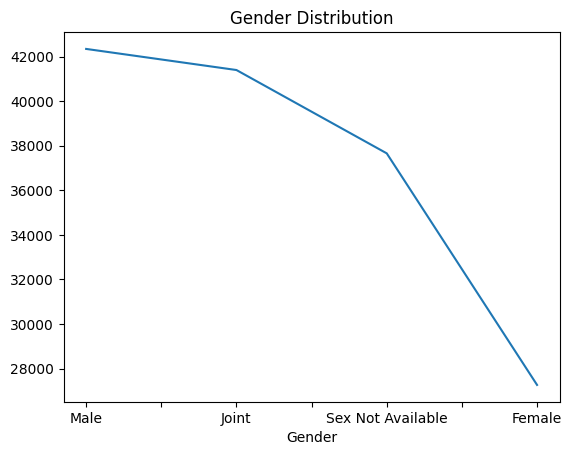

In [13]:
#gender distribution
gender_dist = data['Gender'].value_counts()
gender_dist.plot(kind='line')
plt.title('Gender Distribution')
plt.show()

Text(0.5, 1.0, '% of Approve distribution')

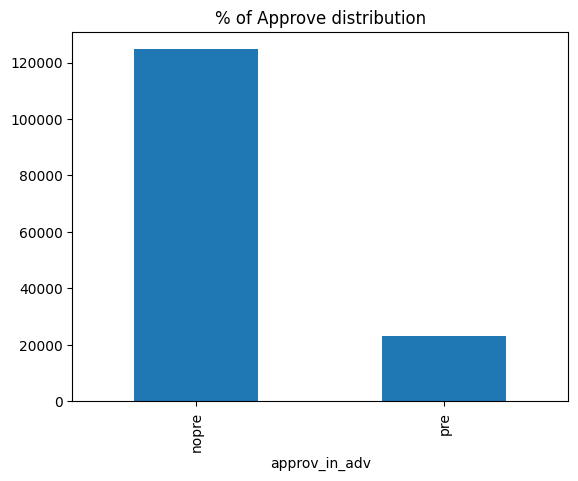

In [14]:
#approvein advance distribution
approve_in = data['approv_in_adv'].value_counts()
approve_in.plot(kind='bar')
plt.title('% of Approve distribution')

In [15]:
#most requested type of loan 
data.groupby('loan_type')['Status'].value_counts()

loan_type  Status
type1      0         87398
           1         25775
type2      0         13590
           1          7172
type3      0         11043
           1          3692
Name: count, dtype: int64

In [16]:
#loan limit and approva rate 
data.groupby('loan_limit')['Status'].value_counts()

loan_limit  Status
cf          0         102904
            1          32444
ncf         0           6664
            1           3314
Name: count, dtype: int64

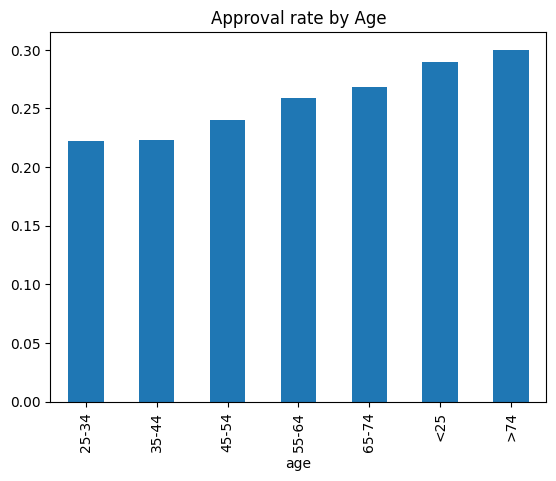

In [17]:
#agegroup and aproval rate
age_group = data.groupby('age')['Status'].mean()
age_group.plot(kind='bar')
plt.title('Approval rate by Age')
plt.show()

In [18]:
#extracting the numerical column
numerical_column = data.select_dtypes(include='number')

In [19]:
numerical_column.columns

Index(['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

In [20]:
#correlation between the numerical data
numerical_column.corr()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
loan_amount,1.000000,-0.150844,-0.377272,0.065556,0.174474,0.734249,0.456065,0.004438,0.038869,-0.036825,0.015029
rate_of_interest,-0.150844,1.000000,0.614908,-0.076473,0.209330,-0.122613,-0.041809,-0.001331,-0.000220,0.022957,0.055124
Interest_rate_spread,-0.377272,0.614908,1.000000,0.033037,-0.157139,-0.334571,-0.151333,-0.001738,0.040257,NaN,0.078178
Upfront_charges,0.065556,-0.076473,0.033037,1.000000,-0.054960,0.053043,0.016580,-0.001484,-0.031347,-0.019138,0.000115
term,0.174474,0.209330,-0.157139,-0.054960,1.000000,0.045117,-0.053785,-0.003149,0.106834,-0.000240,0.110572
property_value,0.734249,-0.122613,-0.334571,0.053043,0.045117,1.000000,0.414883,0.002430,-0.215102,-0.048864,-0.056288
income,0.456065,-0.041809,-0.151333,0.016580,-0.053785,0.414883,1.000000,0.000802,-0.066203,-0.065119,-0.267807
Credit_Score,0.004438,-0.001331,-0.001738,-0.001484,-0.003149,0.002430,0.000802,1.000000,-0.005533,0.004004,-0.000313
LTV,0.038869,-0.000220,0.040257,-0.031347,0.106834,-0.215102,-0.066203,-0.005533,1.000000,0.038895,0.156557
Status,-0.036825,0.022957,NaN,-0.019138,-0.000240,-0.048864,-0.065119,0.004004,0.038895,1.000000,0.078083


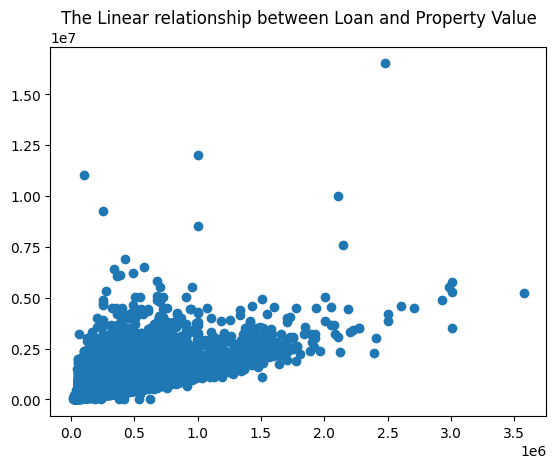

In [21]:
#feature relationship
plt.scatter(data=numerical_column, x='loan_amount', y='property_value')
plt.title('The Linear relationship between Loan and Property Value')
plt.show()

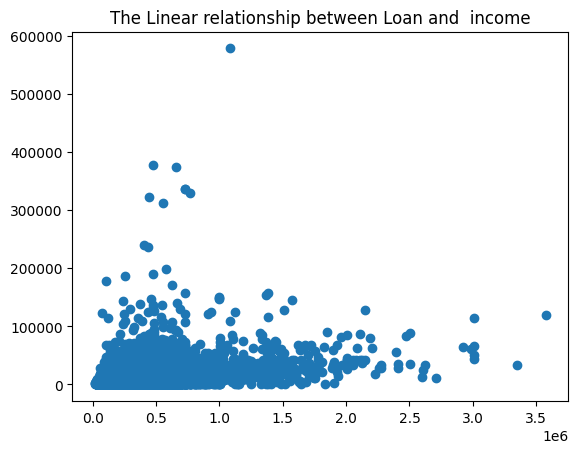

In [22]:
#feature relationship
plt.scatter(data=numerical_column, x='loan_amount', y='income')
plt.title('The Linear relationship between Loan and  income')
plt.show()

In [23]:
numerical_column.columns

Index(['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

<Axes: >

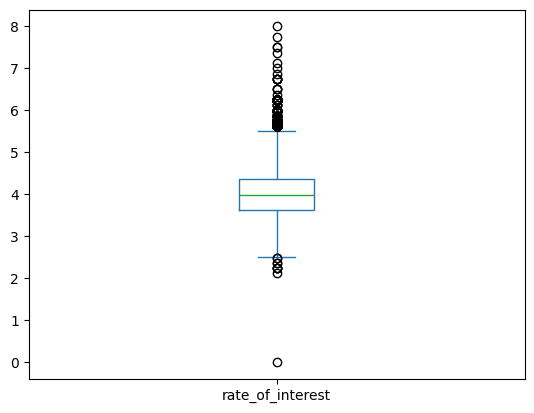

In [24]:
#numerical data distributions
numerical_column['rate_of_interest'].plot(kind='box')

<Axes: ylabel='Frequency'>

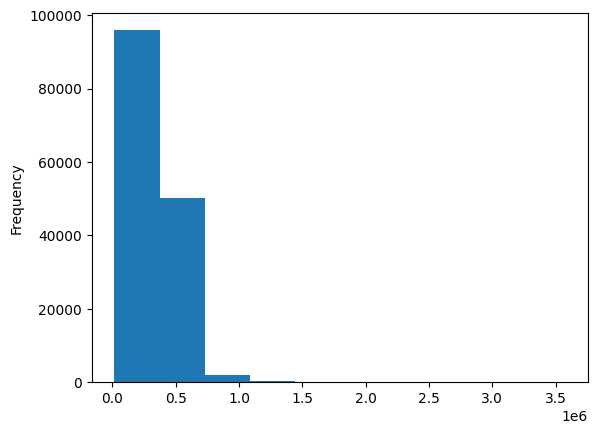

In [25]:
#numerical data distribution
numerical_column['loan_amount'].plot(kind='hist')

<Axes: >

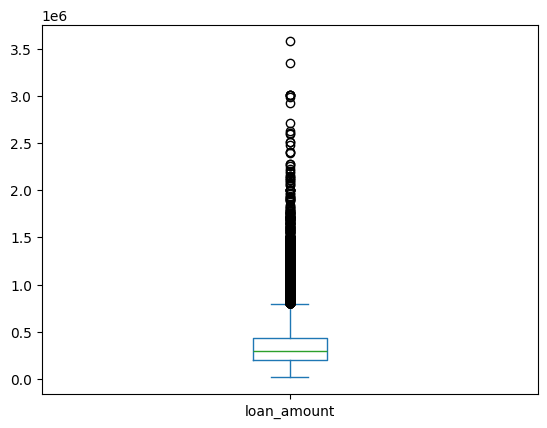

In [26]:
#numerical data distribution
numerical_column['loan_amount'].plot(kind='box')

In [27]:
num = data.select_dtypes(include='number')

In [28]:
#chekcing the skew
num.skew()

loan_amount               1.666998
rate_of_interest          0.388406
Interest_rate_spread      0.280762
Upfront_charges           1.754076
term                     -2.174822
property_value            4.586276
income                   17.307695
Credit_Score              0.004767
LTV                     120.615337
Status                    1.176762
dtir1                    -0.551465
dtype: float64

Splitting Dataset

In [29]:
#splitting the data set
X = data.drop('Status',axis=1)
y = data['Status']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

USING MACHINE LEARNING PIPELINE

In [31]:
#the pipeline for mean and mode for the missing value
missing_value_mode = Pipeline(steps=[
    ("imputation_mode",SimpleImputer(strategy='most_frequent'))])
#the pipeline for mean and mode for the missing value
missing_value_mean = Pipeline(steps=[
    ("imputation_mean",SimpleImputer(strategy='mean'))])

In [32]:

%%writefile custom_transformers.py
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
def winsorize(X, lower=0.25, upper=0.75):
    Q1 = np.percentile(X, lower * 100, axis=0)
    Q3 = np.percentile(X, upper * 100, axis=0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return np.clip(X, lower_bound, upper_bound)

class NamedWinsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.05, upper=0.95):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.feature_names_ = list(X.columns)
        return self

    def transform(self, X):
        return pd.DataFrame(winsorize(X, self.lower, self.upper),
                            columns=self.feature_names_, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_)

Writing custom_transformers.py


In [33]:
#confirm the custom transformer
import os
os.listdir()

['custom_transformers.py', '.virtual_documents']

In [34]:
#so many outlier , sorting with IQR
numerical_column = ['rate_of_interest',
                    'loan_amount',
                    'Credit_Score',
                    'Interest_rate_spread', 
                    'Upfront_charges', 
                    'term', 
                    'property_value', 
                    'income', 
                    'LTV', 
                    'dtir1']

In [35]:
#the custom outlier capping 
from custom_transformers import winsorize, NamedWinsorizer

winsorization_pipeline = Pipeline(steps=[
    ("winsorization", NamedWinsorizer(lower=0.05, upper=0.95))
])

In [36]:
#pipeline for the categorical data for one hot encoder for the categorical data 
one_hot_encoder = Pipeline(steps=[
    ('onehot', SklearnOHE(handle_unknown='ignore',sparse_output=False))
])

In [37]:
# Categorical columns split by encoder type

mode_cols = ['Neg_ammortization', 'submission_of_application', 'age', 
             'loan_limit', 'approv_in_adv', 'loan_purpose'] 

mean_cols = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 
             'term', 'property_value', 'income', 'LTV', 'dtir1'] 

numerical_column = ['loan_amount', 'Credit_Score']  

onehot_cols = ['Gender', 'loan_type', 'occupancy_type', 'total_units', 
               'credit_type', 'Region']

binary_cols = ['Credit_Worthiness', 'open_credit', 'business_or_commercial', 
               'interest_only', 'lump_sum_payment', 'construction_type', 
               'Secured_by', 'Security_Type', 'co-applicant_credit_type']

In [38]:
#combine the two labels column for ordinal encoder and filling the missing value 
mode_binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', 
    unknown_value=-1)) 
])

preprocess = ColumnTransformer([
    ("mode_binary",       mode_binary_pipeline,  mode_cols),        
    ("missingvalue_mean", missing_value_mean,     mean_cols),    
    ("outlier_capping",   winsorization_pipeline, numerical_column),  
    ("onehotencoder",     one_hot_encoder,         onehot_cols),         
    ("binaryencoder",    OrdinalEncoder(handle_unknown='use_encoded_value', 
                                         unknown_value=-1),        binary_cols),        
], remainder='drop')

In [39]:
#preprocess diagram
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mode_binary', ...), ('missingvalue_mean', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_

In [40]:
#hyperparameter tuning parameter settings
grid = {
    'xgbclassifier__n_estimators': [100, 200, 300],
    'xgbclassifier__max_depth': [3, 5, 6],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__subsample': [0.7, 0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.7, 0.8, 1.0]
}

In [41]:
pipe = Pipeline(steps=[
    ('columntransformer', preprocess),
    ('xgbclassifier', XGBClassifier())
])

In [42]:
X_sample, y_sample = resample(X_train, y_train, n_samples=10000, random_state=42)
rs = RandomizedSearchCV(pipe, param_distributions=grid, n_iter=20, cv=5, 
                        scoring='roc_auc', random_state=42)
rs.fit(X_sample, y_sample)
pipe = rs.best_estimator_

In [43]:
print("Best params:", rs.best_params_)
print("Best score:", rs.best_score_)

Best params: {'xgbclassifier__subsample': 1.0, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__max_depth': 5, 'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__colsample_bytree': 0.8}
Best score: 1.0


In [44]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['loan_limit','Gender','approv_in_adv',...,'Region','Security_Type', 'dtir1']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mode_binary', ...), ('missingvalue_mean', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [45]:
#fitting the model 
pipe.fit(X_train,y_train)

y_pred_sm = pipe.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
print('ROC-AUC:',roc_auc_score(y_test,y_pred_sm))
print("Classification Report:\n", classification_report(y_test, y_pred_sm))

Accuracy: 100.0 %

ROC-AUC: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     37056
           1       1.00      1.00      1.00     12006

    accuracy                           1.00     49062
   macro avg       1.00      1.00      1.00     49062
weighted avg       1.00      1.00      1.00     49062



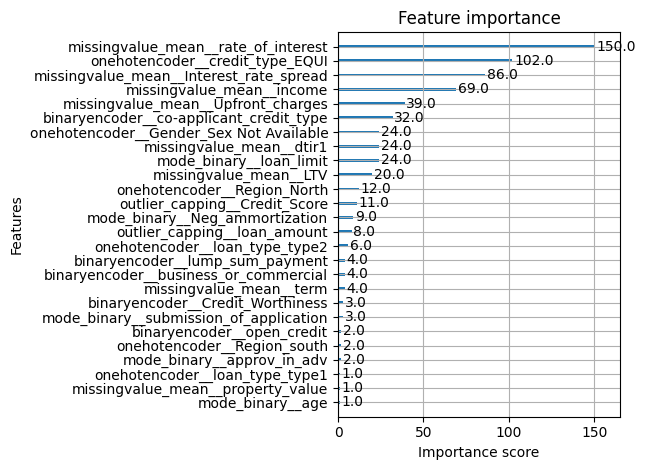

In [46]:
#feature importance
from xgboost import plot_importance
plot_importance(pipe.named_steps['xgbclassifier'], max_num_features=30)
plt.tight_layout()
plt.show()

In [47]:
# Compare train vs test performance for overfitting 
y_train_pred = pipe.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred_sm))

Train accuracy: 1.0
Test accuracy: 1.0


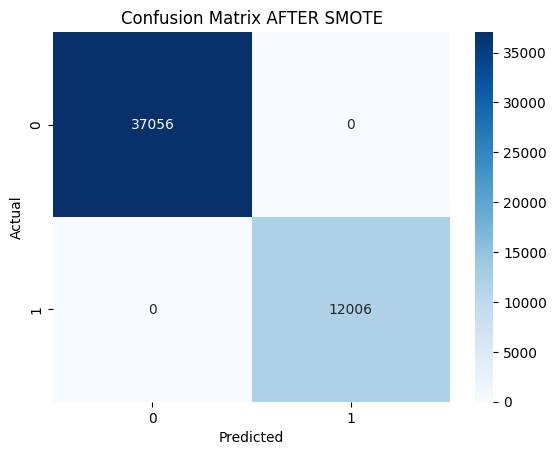

In [48]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
#cross validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X_train, y_train, cv=5)
print(scores)
print(scores.mean())

[1.        1.        1.        1.        0.9999498]
0.9999899603433562


In [50]:
import joblib
joblib.dump(pipe, 'loan_pipeline.pkl')

['loan_pipeline.pkl']